In [2]:
# Warnings
import warnings
warnings.filterwarnings('ignore')

# Utilities
from func import UtilityPipelines

# Libraries
import numpy as np
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [4]:
pipe = UtilityPipelines()

data = pipe.get_lastest_train_data()

Data range: 2014-12-18 to 2024-12-19


In [5]:
data["year"] = data["date"].apply(lambda value: pd.to_datetime(value).year)
data["month"] = data["date"].apply(lambda value: pd.to_datetime(value).month)
data["day"] = data["date"].apply(lambda value: pd.to_datetime(value).day)
data["day_of_week"] = data["date"].apply(lambda value: pd.to_datetime(value).dayofweek)

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

week_days_map = { k : days[k] for k in range( len(days) ) }

data["day_of_week"] = data["day_of_week"].map(week_days_map)

data["date"] = pd.to_datetime(data["date"])
data = data.set_index("date")

In [6]:
data["close"].min(), data["close"].max()

(0.95962, 1.251)

In [7]:
data["close"].min(), 

(0.95962,)

In [8]:
for year in data["year"].unique():
    globals()[f"data_{year}"] = data[data["year"] == year]

In [9]:
# Using 2024 for testing
test_data = data[data["year"] == 2024]
data = data[(data["year"] != 2014) & (data["year"] != 2024)]

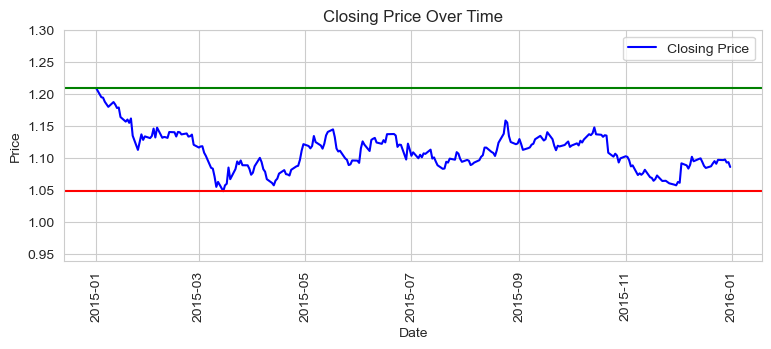

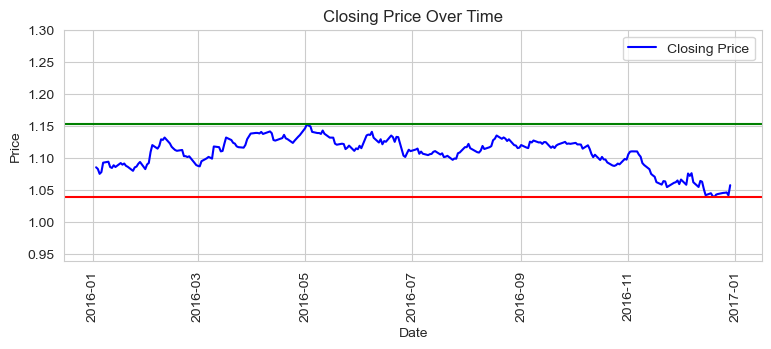

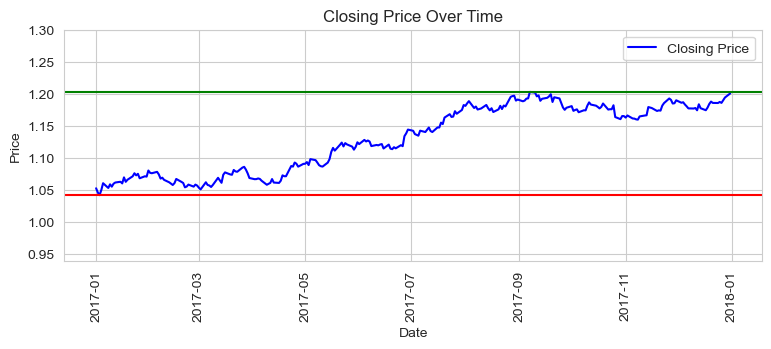

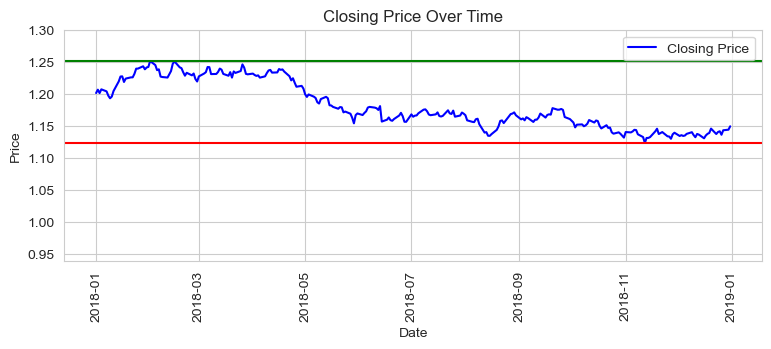

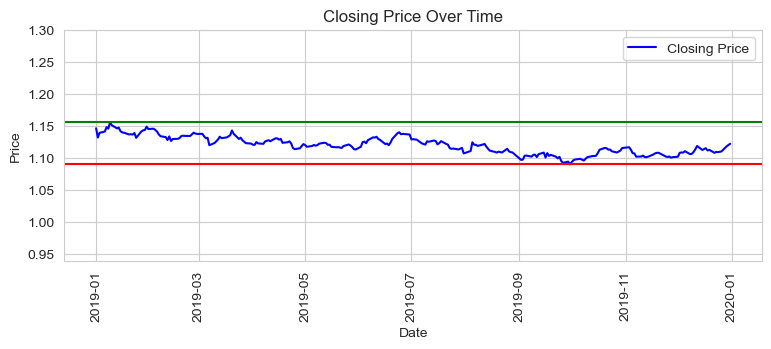

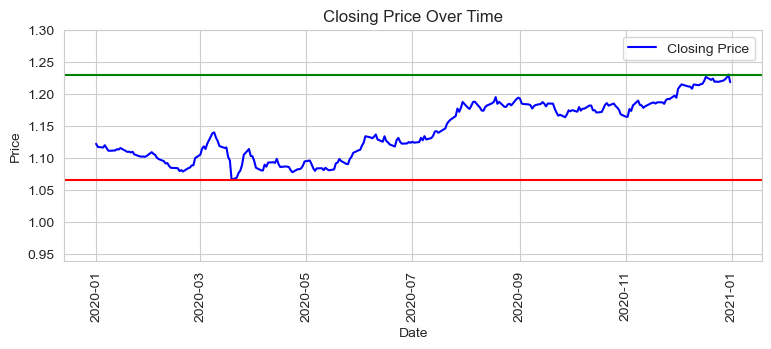

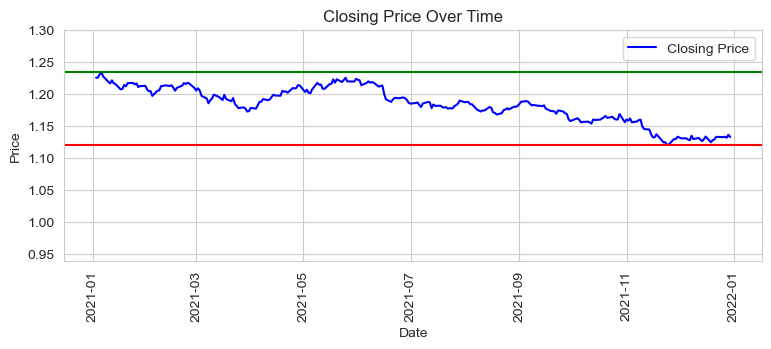

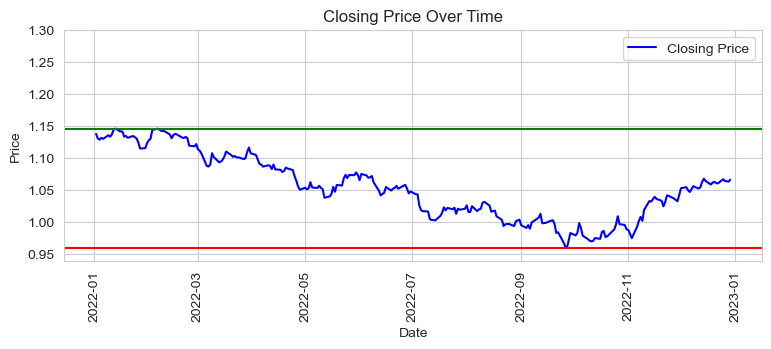

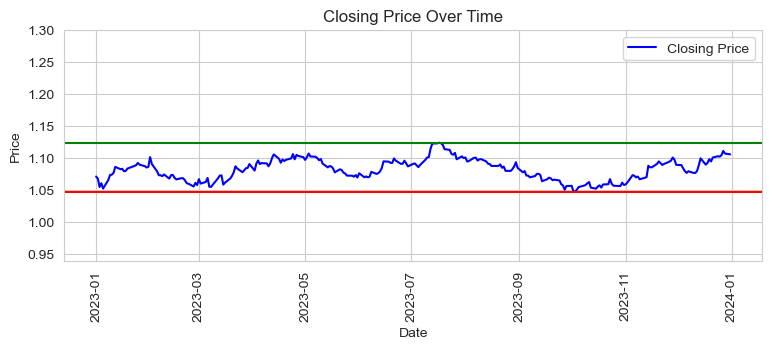

In [12]:
years = [data_2015, data_2016, data_2017, data_2018, data_2019, data_2020, data_2021, data_2022, data_2023]

def plot_year(data):
    plt.figure(figsize=(9, 3))
    plt.plot(data.index, data['close'], label='Closing Price', color='blue')
    plt.title('Closing Price Over Time')
    plt.axhline(data["close"].max(), c="g")
    plt.axhline(data["close"].min(), c="r")
    plt.xticks(rotation=90)
    plt.xlabel('Date')
    plt.ylim( 0.94 , 1.3  )
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

for year in years:
    plot_year(year)
    

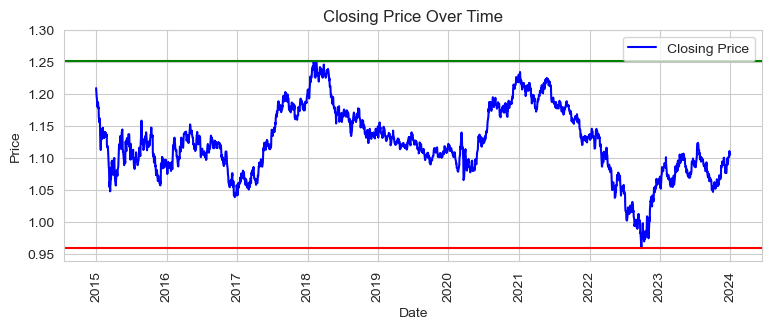

In [13]:
plot_year(data[(data["year"] != "2014") & (data["year"] != "2024")])

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

def transform_data(data: pd.DataFrame):
    
    temp = data["close"].values.reshape(-1, 1)
    temp_scaled = scaler.fit_transform(temp)

    return temp_scaled

def create_sequecences(data: pd.DataFrame, length: int):

    X, y = [], []

    for value in range(len(data) - length):
        X.append(data[value:value + length])
        y.append(data[value + length])

    return np.array(X), np.array(y)

In [17]:
# Sequence lenght
sequence_length = 50

In [18]:
train_data = transform_data(data)
test_data = transform_data(test_data)

In [19]:
X_train, y_train = create_sequecences(train_data, sequence_length)
X_test, y_test = create_sequecences(test_data, sequence_length)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential([
    GRU(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)  # Predict the next price
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(
    X_train, y_train,
    epochs=300,  
    batch_size=31,
    validation_split=0.2,  
    verbose=2
)

Epoch 1/300
60/60 - 2s - 27ms/step - loss: 0.0245 - val_loss: 0.0014
Epoch 2/300
60/60 - 0s - 8ms/step - loss: 6.3639e-04 - val_loss: 0.0010
Epoch 3/300
60/60 - 0s - 8ms/step - loss: 4.6725e-04 - val_loss: 9.2604e-04
Epoch 4/300
60/60 - 0s - 8ms/step - loss: 4.6186e-04 - val_loss: 9.8230e-04
Epoch 5/300
60/60 - 0s - 8ms/step - loss: 4.2924e-04 - val_loss: 8.4584e-04
Epoch 6/300
60/60 - 0s - 7ms/step - loss: 4.1513e-04 - val_loss: 8.1106e-04
Epoch 7/300
60/60 - 0s - 7ms/step - loss: 4.1018e-04 - val_loss: 8.0815e-04
Epoch 8/300
60/60 - 0s - 7ms/step - loss: 3.8818e-04 - val_loss: 7.8956e-04
Epoch 9/300
60/60 - 0s - 8ms/step - loss: 3.7610e-04 - val_loss: 7.5513e-04
Epoch 10/300
60/60 - 0s - 8ms/step - loss: 3.9278e-04 - val_loss: 7.4515e-04
Epoch 11/300
60/60 - 0s - 8ms/step - loss: 3.7966e-04 - val_loss: 7.4990e-04
Epoch 12/300
60/60 - 0s - 8ms/step - loss: 3.8639e-04 - val_loss: 7.4392e-04
Epoch 13/300
60/60 - 0s - 8ms/step - loss: 3.7230e-04 - val_loss: 7.1717e-04
Epoch 14/300
60/60 

In [21]:
# Evaluating the test data
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (2024): {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test)

# Inverse transform to get actual prices
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 
Test Loss (2024): 0.002094557508826256
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


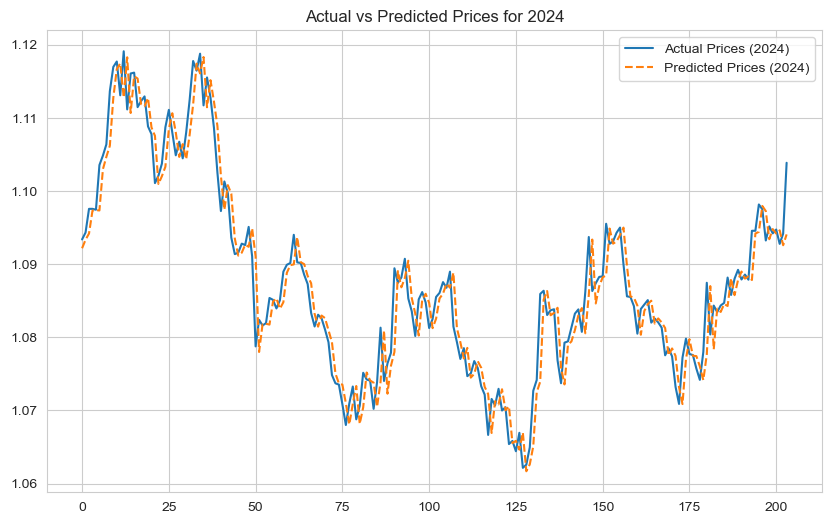

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual Prices (2024)')
plt.plot(y_pred_actual, label='Predicted Prices (2024)', linestyle='--')
plt.title('Actual vs Predicted Prices for 2024')
plt.legend()
plt.show()